In [1]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [2]:
env_path = Path("/Users/trba/Documents/Projects/Serbia_housing/.env.aws")
load_dotenv(env_path)

True

In [6]:
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [7]:
df = pd.read_sql("SELECT datum_objave,price_total,kvadratura FROM gold.unified_deduplicated",engine)

In [10]:
df['datum_objave'] = pd.to_datetime(df['datum_objave'])
df = df[df['datum_objave'] >= '2025-01-01'].copy()
df['price_per_m2_cal'] = df['price_total'] / df['kvadratura']

In [11]:
q_low = df['price_per_m2_cal'].quantile(0.01)
q_high = df['price_per_m2_cal'].quantile(0.99)
df = df[df['price_per_m2_cal'].between(q_low,q_high)].copy()

In [12]:
print(f"Oglasa: {len(df)}")
print(f"Raspon: {df['datum_objave'].min().date()} -> {df['datum_objave'].max().date()}")

Oglasa: 21974
Raspon: 2025-01-05 -> 2026-05-15


In [13]:
df['nedelja'] = df['datum_objave'].dt.to_period("W-MON").apply(lambda p : p.start_time)

In [30]:
weekly = df.groupby('nedelja')['price_per_m2_cal'].agg(
    medijana ='median',
    p25 = lambda x : x.quantile(0.25),
    p75 = lambda x : x.quantile(0.75),
    broj_oglasa = 'count'
).reset_index()

print(weekly)

      nedelja     medijana          p25          p75  broj_oglasa
0  2024-12-31  3294.871795  2794.823957  3302.365475            3
1  2025-01-07  3375.000000  2000.000000  4024.390244            9
2  2025-01-14  3694.066036  2640.008128  4474.870083           16
3  2025-01-21  3250.000000  2580.645161  3333.333333            9
4  2025-01-28  3058.823529  2379.273912  3818.965517           11
..        ...          ...          ...          ...          ...
67 2026-04-14  3271.186441  2613.636364  4000.000000         2541
68 2026-04-21  3333.333333  2663.971648  4201.898734         2870
69 2026-04-28  2900.000000  1822.192513  3957.595527         2004
70 2026-05-05  2826.364684  1791.552632  3812.395485         1064
71 2026-05-12  2927.712363  1966.546474  4027.213463          834

[72 rows x 5 columns]


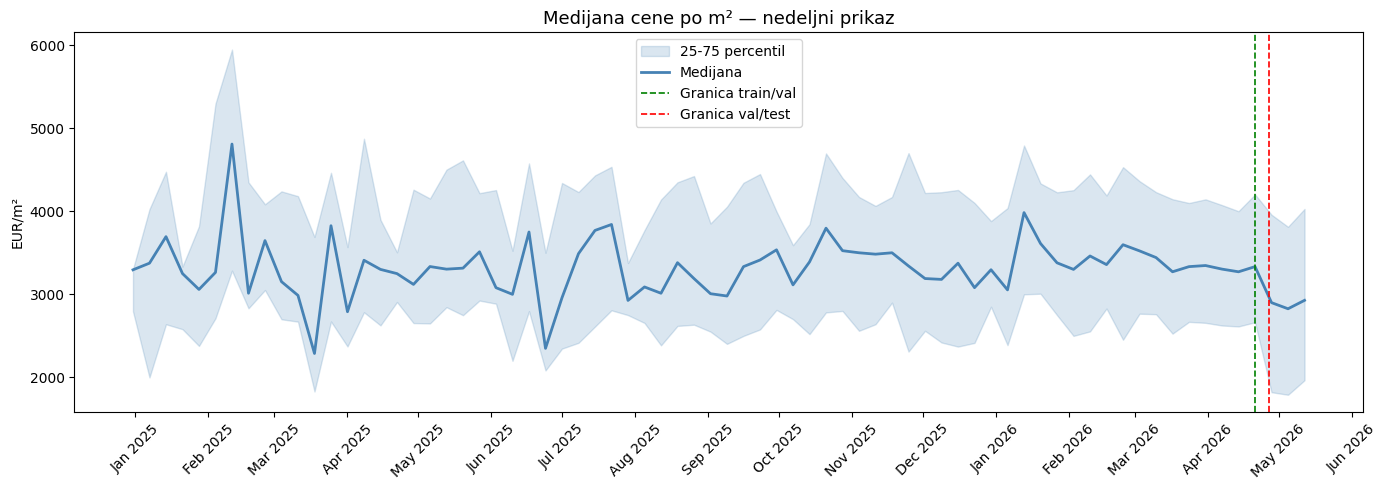

In [22]:
fix,ax = plt.subplots(figsize=(14,5))

ax.fill_between(
    weekly['nedelja'],
    weekly['p25'],
    weekly['p75'],
    alpha = 0.2, color = 'steelblue', label = '25-75 percentil'
)
ax.plot(
    weekly['nedelja'],
    weekly['medijana'],
    color="steelblue", linewidth=2, label="Medijana"
)
ax.axvline(pd.Timestamp("2026-04-21"), color="green", linestyle="--", linewidth=1.2, label="Granica train/val")
ax.axvline(pd.Timestamp("2026-04-27"), color="red",    linestyle="--", linewidth=1.2, label="Granica val/test")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.set_title("Medijana cene po m² — nedeljni prikaz", fontsize=13)
ax.set_ylabel("EUR/m²")
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()


/var/folders/8n/t9qxl3yn7615w9l35j5w328m0000gn/T/ipykernel_2114/3146275923.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


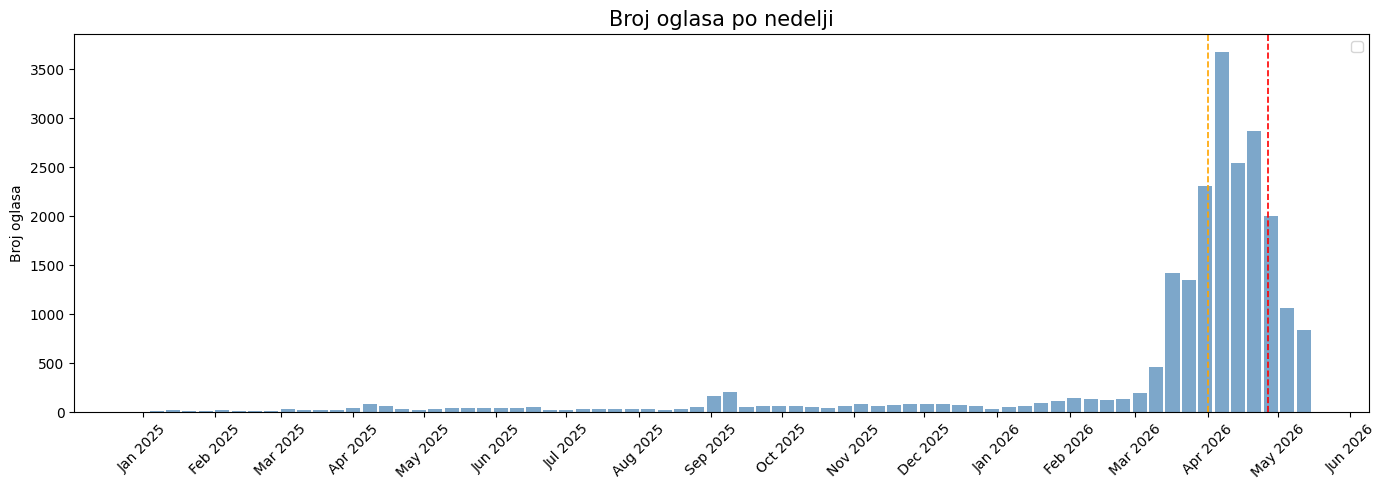

In [29]:
fix,ax = plt.subplots(figsize=(14,5))

ax.bar(
    weekly['nedelja'],
    weekly['broj_oglasa'],
    width=6, color="steelblue", alpha=0.7
)
ax.axvline(pd.Timestamp('2026-04-01'), color = 'orange', linestyle = '--', linewidth = 1.2)
ax.axvline(pd.Timestamp('2026-04-27'), color = 'red', linestyle = '--', linewidth = 1.2)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation = 45)

ax.set_title('Broj oglasa po nedelji', fontsize = 15)
ax.set_ylabel('Broj oglasa')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
df = pd.read_sql("""
    SELECT oglas_id, datum_objave, created_at, price_total, kvadratura, lokacija
    FROM gold.unified_deduplicated
    ORDER BY created_at
""", engine)

df["datum_objave"]        = pd.to_datetime(df["datum_objave"])
df["datum_scrapovanja"]   = pd.to_datetime(df["created_at"])
df["starost_pri_scrapovanju"] = (df["datum_scrapovanja"] - df["datum_objave"]).dt.days

print(df["starost_pri_scrapovanju"].describe())
print(df[df["starost_pri_scrapovanju"] > 30].shape[0], "oglasa starijih od 30 dana pri scrapovanju")

count    23037.000000
mean        56.757955
std        189.569289
min         -6.000000
25%          1.000000
50%          2.000000
75%         19.000000
max       3578.000000
Name: starost_pri_scrapovanju, dtype: float64
4147 oglasa starijih od 30 dana pri scrapovanju


In [37]:
# Sortiraj po starosti da vidis najsumnjivije
sumnjivi = df[df["starost_pri_scrapovanju"] > 365].sort_values("starost_pri_scrapovanju", ascending=False)
print(sumnjivi[["oglas_id", "datum_objave", "datum_scrapovanja", "starost_pri_scrapovanju", "kvadratura", "lokacija"]].head(20))

      oglas_id datum_objave          datum_scrapovanja  \
16212   284310   2016-06-29 2026-04-16 05:17:04.474359   
16195   289758   2016-12-12 2026-04-16 05:15:26.835617   
17788    14766   2017-02-27 2026-04-16 08:13:36.656511   
15626    21568   2017-06-21 2026-04-16 04:13:50.669703   
17789    28100   2017-08-09 2026-04-16 08:13:36.656511   
16445     1282   2017-09-04 2026-04-16 05:41:50.478504   
16447    41404   2017-10-23 2026-04-16 05:43:32.022604   
16463    23814   2017-10-23 2026-04-16 05:43:32.022604   
16211   526835   2017-12-29 2026-04-16 05:17:04.474359   
16428   181087   2018-03-07 2026-04-16 05:41:50.478504   
1776    664845   2018-04-08 2026-04-09 22:23:42.470746   
12955   675387   2018-04-15 2026-04-15 22:03:42.532881   
14825   680874   2018-04-18 2026-04-16 02:43:53.612713   
3929    674197   2018-04-14 2026-04-10 02:40:02.769613   
15492  1607890   2018-07-19 2026-04-16 03:59:56.441076   
16050  1867955   2018-12-20 2026-04-16 04:59:03.402786   
16045  1867919

In [48]:
df["price_per_m2_cal"] = df["price_total"] / df["kvadratura"]

In [49]:
df = df[df['datum_objave'].notna()].copy()
df['mesec'] = df['datum_objave'].dt.to_period('M').apply(lambda x: x.start_time)

In [51]:
monthly = df.groupby('mesec')['price_per_m2_cal'].agg(
    medijana ='median',
    p25 = lambda x : x.quantile(0.25),
    p75 = lambda x : x.quantile(0.75),
    broj_oglasa = 'count'
).reset_index()

print(monthly)

        mesec     medijana          p25          p75  broj_oglasa
0  2016-06-01  2894.736842  2894.736842  2894.736842            1
1  2016-12-01  1303.418803  1303.418803  1303.418803            1
2  2017-02-01  5072.168675  5072.168675  5072.168675            1
3  2017-06-01  8076.923077  8076.923077  8076.923077            1
4  2017-08-01  1971.830986  1971.830986  1971.830986            1
..        ...          ...          ...          ...          ...
80 2026-01-01  3518.918919  2713.636364  4330.128205          319
81 2026-02-01  3461.538462  2571.428571  4518.497600          549
82 2026-03-01  3349.397590  2641.650239  4202.317254         3771
83 2026-04-01  3300.000000  2603.260870  4116.515837        12247
84 2026-05-01  2752.893636  1500.000000  3852.232964         3142

[85 rows x 5 columns]


In [61]:
monthly_filtered = monthly[monthly['broj_oglasa'] >= 100]

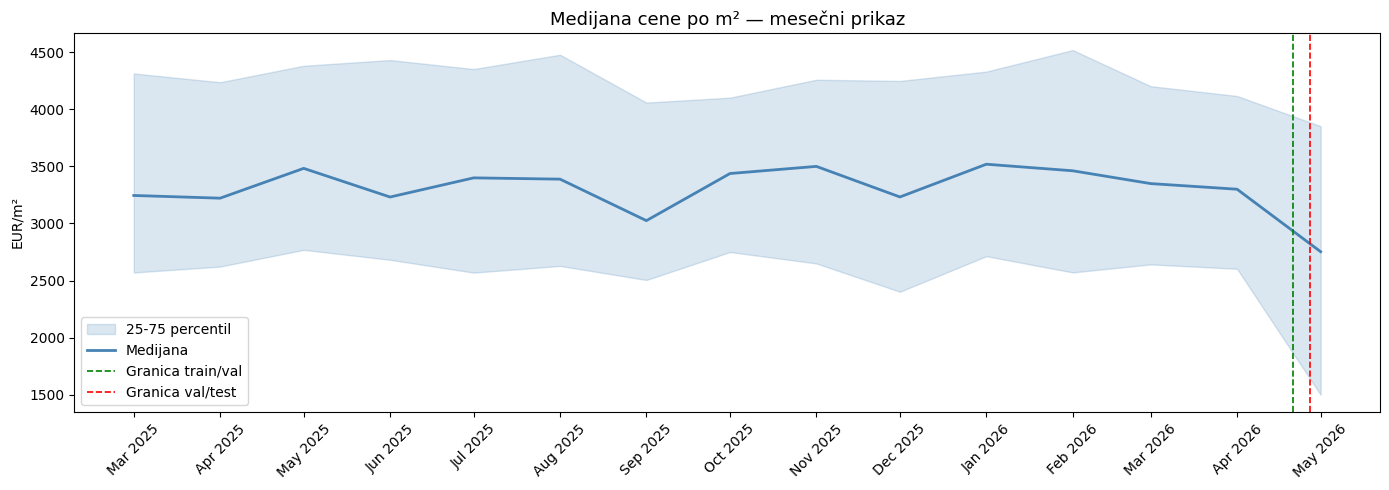

In [64]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    monthly_filtered['mesec'],
    monthly_filtered['p25'],
    monthly_filtered['p75'],
    alpha=0.2, color='steelblue', label='25-75 percentil'
)
ax.plot(
    monthly_filtered['mesec'],
    monthly_filtered['medijana'],
    color='steelblue', linewidth=2, label='Medijana'
)

ax.axvline(pd.Timestamp("2026-04-21"), color="green", linestyle="--", linewidth=1.2, label="Granica train/val")
ax.axvline(pd.Timestamp("2026-04-27"), color="red",    linestyle="--", linewidth=1.2, label="Granica val/test")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.set_title("Medijana cene po m² — mesečni prikaz", fontsize=13)
ax.set_ylabel("EUR/m²")
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/8n/t9qxl3yn7615w9l35j5w328m0000gn/T/ipykernel_2114/278637619.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_po_mesecu, labels=labele, showfliers=False, patch_artist=True,


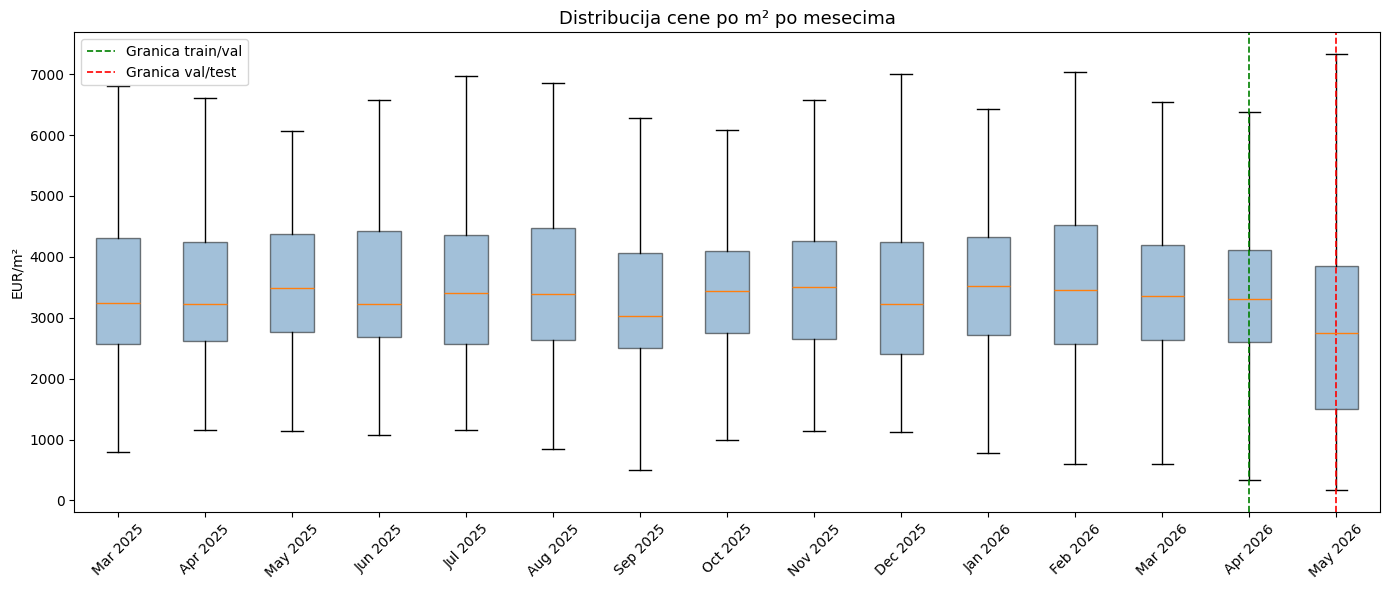

In [65]:
df_filtered = df[df['mesec'].isin(monthly_filtered['mesec'])]

fig, ax = plt.subplots(figsize=(14, 6))

meseci = sorted(df_filtered['mesec'].unique())
data_po_mesecu = [df_filtered[df_filtered['mesec'] == m]['price_per_m2_cal'].values for m in meseci]
labele = [m.strftime("%b %Y") for m in meseci]

ax.boxplot(data_po_mesecu, labels=labele, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5))

ax.axvline(labele.index("Apr 2026") + 1, color="green", linestyle="--", linewidth=1.2, label="Granica train/val")
ax.axvline(labele.index("May 2026") + 1, color="red",   linestyle="--", linewidth=1.2, label="Granica val/test")

plt.xticks(rotation=45)
ax.set_title("Distribucija cene po m² po mesecima", fontsize=13)
ax.set_ylabel("EUR/m²")
ax.legend()
plt.tight_layout()
plt.show()